# STCT for Regression: A TSER Archive Benchmark

The classification notebook in this project established that STCT is a
strong *feature set*, one well-known application of having a signal
transform at all, alongside wavelet and STFT. This notebook tests the other
half of that claim directly: **does STCT work for regression too?**

Same fairness principle as the classification benchmark: Wavelet, STFT, and
STCT features are all raw (no representation gets a compression step the
others are denied), classified... here, *regressed*, with an identical,
unmodified `RandomForestRegressor`. Rocket is reported as external context
via `RocketRegressor`, with feature-extraction and regressor time measured
as two direct, additive quantities (the same fix the classification
notebook needed after an earlier subtraction-based attempt failed).

Datasets are 26 from the **Monash/UEA/UCR Time Series Extrinsic Regression
(TSER) archive** via `aeon.datasets.load_regression` — continuous targets
(concentrations, contamination levels, flood heights, power output, price
sentiment, etc.), not class labels.


In [1]:
# 1. Install dependencies (Colab)
!pip install -q aeon pywavelets scikit-learn scipy matplotlib pandas


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from scipy.signal import stft
from scipy import stats
from numpy.polynomial import chebyshev as C

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from aeon.datasets import load_regression
from aeon.transformations.collection.convolution_based import Rocket

RNG = 42
np.random.seed(RNG)


## 2. Feature representations

Identical to the classification notebook: raw DWT coefficients, raw STFT
magnitude spectrogram, and STCT (fast vectorized Chebyshev fit + residual,
proper multi-scale). No changes needed for regression, since these produce
a feature vector regardless of what the downstream model does with it,
exactly the point of Section IV in the accompanying paper.


In [3]:
def wavelet_features(X, wavelet="db4", level=None):
    """Raw DWT coefficients, concatenated across levels no summarization."""
    feats = []
    for row in X:
        max_level = pywt.dwt_max_level(len(row), pywt.Wavelet(wavelet).dec_len)
        lvl = level or min(4, max_level)
        coeffs = pywt.wavedec(row, wavelet, level=lvl)
        feats.append(np.concatenate([np.asarray(c) for c in coeffs]))
    return np.vstack(feats)

def stft_features(X, nperseg=32, noverlap=None):
    """Raw STFT magnitude spectrogram, flattenedno summarization."""
    noverlap = noverlap or nperseg // 2
    feats = []
    for row in X:
        seg = min(nperseg, len(row))
        _, _, Zxx = stft(row, nperseg=seg, noverlap=min(noverlap, seg - 1))
        feats.append(np.abs(Zxx).ravel())
    return np.vstack(feats)


In [4]:
def _safe_cheby_params(n, n_windows=8, degree=4):
    """Shrink degree/n_windows to whatever the available length can support."""
    degree = max(1, min(degree, n - 2))
    if n >= degree + 2:
        n_windows = max(1, min(n_windows, n // (degree + 2)))
    else:
        n_windows = 1
        degree = max(1, n - 2)
    return n_windows, degree

def _cheby_design(win_len, deg):
    x = np.linspace(-1, 1, win_len)
    Phi = C.chebvander(x, deg)
    return Phi, np.linalg.pinv(Phi)

def _windowed_chebyshev_single_scale(X, n_windows, degree, include_residual=True):
    X = np.asarray(X)
    n_samples, n = X.shape
    nw, deg = _safe_cheby_params(n, n_windows, degree)
    win_len = min(max(deg + 2, n // nw), n)
    step = max(1, (n - win_len) // max(1, nw - 1))
    starts = np.array(list(range(0, n - win_len + 1, step))[:nw])
    actual_nw = len(starts)

    Phi, pinv = _cheby_design(win_len, deg)
    idx = starts[:, None] + np.arange(win_len)[None, :]
    windows = X[:, idx]
    coefs = windows @ pinv.T

    if include_residual:
        recon = coefs @ Phi.T
        resid_rms = np.sqrt(((windows - recon) ** 2).mean(axis=-1, keepdims=True))
        block = np.concatenate([coefs, resid_rms], axis=-1)
    else:
        block = coefs

    if actual_nw < nw:
        pad = np.zeros((n_samples, nw - actual_nw, block.shape[-1]))
        block = np.concatenate([block, pad], axis=1)
    return block.reshape(n_samples, nw * block.shape[-1])

def windowed_chebyshev_features(X, window_counts=(8, 16), degree=4, include_residual=True):
    parts = [_windowed_chebyshev_single_scale(X, nw, degree, include_residual) for nw in window_counts]
    return np.concatenate(parts, axis=1)


In [5]:
# --- sanity check across problem lengths ---
for n in [24, 84, 96, 601, 1250]:
    X = np.random.randn(5, n).cumsum(axis=1)
    for name, fn in [("wavelet", wavelet_features), ("stft", stft_features),
                      ("stct", windowed_chebyshev_features)]:
        f = fn(X)
        assert not np.isnan(f).any(), (n, name)
print("All three feature extractors OK across tested lengths.")


All three feature extractors OK across tested lengths.


## 3. Dataset list and runtime configuration

TSER datasets vary a lot in size and series length (from Covid3Month's 140
examples of length 84 to sensor-array datasets with hundreds of long
readings). Caps below keep the run tractable; widen once confirmed working.


In [6]:
TSER_DATASET_NAMES = [
    "AcousticContaminationMadrid", "AluminiumConcentration", "BoronConcentration",
    "CalciumConcentration", "CopperConcentration", "Covid19Andalusia", "Covid3Month",
    "DhakaHourlyAirQuality", "FloodModeling1", "FloodModeling2", "FloodModeling3",
    "GasSensorArrayAcetone", "GasSensorArrayEthanol", "IronConcentration",
    "LPGasMonitoringHomeActivity", "MagnesiumConcentration", "ManganeseConcentration",
    "MethaneMonitoringHomeActivity", "NaturalGasPricesSentiment", "PhosphorusConcentration",
    "PotassiumConcentration", "SodiumConcentration", "SulphurConcentration",
    "WaveDataTension", "WindTurbinePower", "ZincConcentration",
]
print(f"{len(TSER_DATASET_NAMES)} datasets in the list.")


26 datasets in the list.


In [7]:
MAX_DATASETS = None        # None = attempt all 26
MAX_TRAIN_SIZE = None
MAX_SERIES_LENGTH = None

run_list = TSER_DATASET_NAMES if MAX_DATASETS is None else TSER_DATASET_NAMES[:MAX_DATASETS]
print(f"Will attempt {len(run_list)} of {len(TSER_DATASET_NAMES)} datasets "
      f"(MAX_TRAIN_SIZE={MAX_TRAIN_SIZE}, MAX_SERIES_LENGTH={MAX_SERIES_LENGTH}).")


Will attempt 26 of 26 datasets (MAX_TRAIN_SIZE=None, MAX_SERIES_LENGTH=None).


## 4. Running the benchmark

Regression metrics: RMSE (primary, used for significance testing, standard
in TSER benchmarking), MAE, and R². Feature-extraction and
regressor-fit+predict time are tracked separately and additively for every
representation, including Rocket, using the same fix the classification
notebook needed (`Rocket` transform, `StandardScaler`, `RidgeCV`, replicated
by hand exactly as aeon constructs `RocketRegressor` internally, so both
stages are measured directly rather than one being estimated by
subtraction).


In [8]:
def get_xy(name, split):
    X, y = load_regression(name, split=split)
    X = np.asarray(X)
    if X.ndim == 3:
        X = X[:, 0, :]
    if X.dtype == object or X.ndim != 2:
        raise ValueError(f"{name}: unequal-length series (dtype={X.dtype}, ndim={X.ndim}) "
                          f"not supported by this notebook's fixed-length feature extractors.")
    return X, np.asarray(y, dtype=float)

def evaluate_with_regressor(feat_fn, X_train, y_train, X_test, y_test):
    t0 = time.time()
    F_train = feat_fn(X_train)
    F_test = feat_fn(X_test)
    extract_time = time.time() - t0

    t0 = time.time()
    reg = make_pipeline(StandardScaler(), RandomForestRegressor(
        n_estimators=300, random_state=RNG, n_jobs=-1))
    reg.fit(F_train, y_train)
    preds = reg.predict(F_test)
    regressor_time = time.time() - t0

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    return {"rmse": rmse, "mae": mae, "r2": r2, "n_features": F_train.shape[1],
            "extract_time_s": extract_time, "regressor_time_s": regressor_time}

FEATURE_FNS = {
    "Wavelet": wavelet_features,
    "STFT": stft_features,
    "STCT": windowed_chebyshev_features,
}

full_results = []
full_results_long = []
t_start = time.time()
for name in run_list:
    try:
        X_train, y_train = get_xy(name, "train")
        X_test, y_test = get_xy(name, "test")
    except Exception as e:
        print(f"[skip] {name}: could not load ({e})")
        continue

    if MAX_TRAIN_SIZE is not None and len(X_train) > MAX_TRAIN_SIZE:
        print(f"[skip] {name}: train size {len(X_train)} > MAX_TRAIN_SIZE")
        continue
    if MAX_SERIES_LENGTH is not None and X_train.shape[1] > MAX_SERIES_LENGTH:
        print(f"[skip] {name}: series length {X_train.shape[1]} > MAX_SERIES_LENGTH")
        continue

    row = {"dataset": name, "n_train": len(X_train), "n_test": len(X_test),
           "length": X_train.shape[1]}
    t0 = time.time()
    for rep_name, fn in FEATURE_FNS.items():
        try:
            result = evaluate_with_regressor(fn, X_train, y_train, X_test, y_test)
        except Exception as e:
            print(f"  [warn] {name} / {rep_name} failed: {e}")
            result = {"rmse": np.nan, "mae": np.nan, "r2": np.nan, "n_features": np.nan,
                      "extract_time_s": np.nan, "regressor_time_s": np.nan}
        row[f"{rep_name}_rmse"] = result["rmse"]
        full_results_long.append({"dataset": name, "representation": rep_name, **result})

    try:
        t_extract0 = time.time()
        rocket_tf = Rocket(n_kernels=10000, n_jobs=-1, random_state=RNG)
        Ftr = rocket_tf.fit_transform(X_train[:, None, :])
        Fte = rocket_tf.transform(X_test[:, None, :])
        t_extract = time.time() - t_extract0

        t_reg0 = time.time()
        rk_scaler = StandardScaler(with_mean=False)
        Ftr_s = rk_scaler.fit_transform(Ftr)
        Fte_s = rk_scaler.transform(Fte)
        rk_reg = RidgeCV(alphas=np.logspace(-3, 3, 10))
        rk_reg.fit(Ftr_s, y_train)
        rk_preds = rk_reg.predict(Fte_s)
        t_reg = time.time() - t_reg0

        rk_rmse = np.sqrt(mean_squared_error(y_test, rk_preds))
        row["Rocket_rmse"] = rk_rmse
        full_results_long.append({"dataset": name, "representation": "Rocket",
                                    "rmse": rk_rmse, "mae": mean_absolute_error(y_test, rk_preds),
                                    "r2": r2_score(y_test, rk_preds), "n_features": Ftr.shape[1],
                                    "extract_time_s": t_extract, "regressor_time_s": t_reg})
    except Exception as e:
        print(f"  [warn] {name} / Rocket failed: {e}")
        row["Rocket_rmse"] = np.nan

    full_results.append(row)
    print(f"[{len(full_results)}/{len(run_list)}] {name:28s} done in {time.time()-t0:5.1f}s "
          f"(total elapsed {time.time()-t_start:6.1f}s)")

full_results_df = pd.DataFrame(full_results)
full_results_long_df = pd.DataFrame(full_results_long)
print(f"\nCompleted {len(full_results_df)} datasets in {time.time()-t_start:.1f}s total.")
full_results_df


  [warn] AcousticContaminationMadrid / Rocket failed: Data seen by instance of Rocket has missing values, but Rocket cannot handle these characteristics. 
[1/26] AcousticContaminationMadrid  done in   1.6s (total elapsed    1.7s)
[2/26] AluminiumConcentration       done in  44.3s (total elapsed   47.2s)
[3/26] BoronConcentration           done in  50.8s (total elapsed   98.6s)
[4/26] CalciumConcentration         done in  45.5s (total elapsed  144.7s)
[5/26] CopperConcentration          done in  45.7s (total elapsed  191.1s)
[6/26] Covid19Andalusia             done in   1.4s (total elapsed  192.5s)
[7/26] Covid3Month                  done in   1.3s (total elapsed  193.8s)
[8/26] DhakaHourlyAirQuality        done in   6.0s (total elapsed  199.9s)
[9/26] FloodModeling1               done in   6.5s (total elapsed  206.4s)
[10/26] FloodModeling2               done in   6.0s (total elapsed  212.6s)
[11/26] FloodModeling3               done in   5.4s (total elapsed  218.1s)
[12/26] GasSensorA

,dataset,n_train,n_test,length,Wavelet_rmse,STFT_rmse,STCT_rmse,Rocket_rmse
0,AcousticContaminationMadrid,166,72,365,5.802009,5.167327,5.039324,NaN
1,AluminiumConcentration,440,189,2542,318.760641,266.699930,236.150915,207.073712
2,BoronConcentration,438,188,2542,1.285409,1.295764,1.169735,1.070259
3,CalciumConcentration,444,191,2307,1968.906098,2116.152927,1885.089602,2078.998125
4,CopperConcentration,440,189,2542,1.943615,1.896119,1.812986,1.746653
5,Covid19Andalusia,142,62,91,0.015193,0.016266,0.014084,0.014062
6,Covid3Month,140,61,84,0.040448,0.045877,0.040182,0.039352
7,DhakaHourlyAirQuality,1447,621,24,5.977113,3.970520,5.659578,47.243905
8,FloodModeling1,471,202,266,0.015356,0.012597,0.013107,0.014048
9,FloodModeling2,466,201,266,0.010515,0.010736,0.010641,0.011343


## 5. Results

In [9]:
rep_cols = ["Wavelet", "STFT", "STCT", "Rocket"]
rmse_cols = [f"{r}_rmse" for r in rep_cols]
display_df = full_results_df.set_index("dataset")[rmse_cols].round(4)
display_df.columns = rep_cols
display_df.loc["MEAN"] = display_df.mean()
display_df


,Wavelet,STFT,STCT,Rocket
dataset,,,,
AcousticContaminationMadrid,5.802000,5.167300,5.039300,NaN
AluminiumConcentration,318.760600,266.699900,236.150900,207.073700
BoronConcentration,1.285400,1.295800,1.169700,1.070300
CalciumConcentration,1968.906100,2116.152900,1885.089600,2078.998100
CopperConcentration,1.943600,1.896100,1.813000,1.746700
Covid19Andalusia,0.015200,0.016300,0.014100,0.014100
Covid3Month,0.040400,0.045900,0.040200,0.039400
DhakaHourlyAirQuality,5.977100,3.970500,5.659600,47.243900
FloodModeling1,0.015400,0.012600,0.013100,0.014000


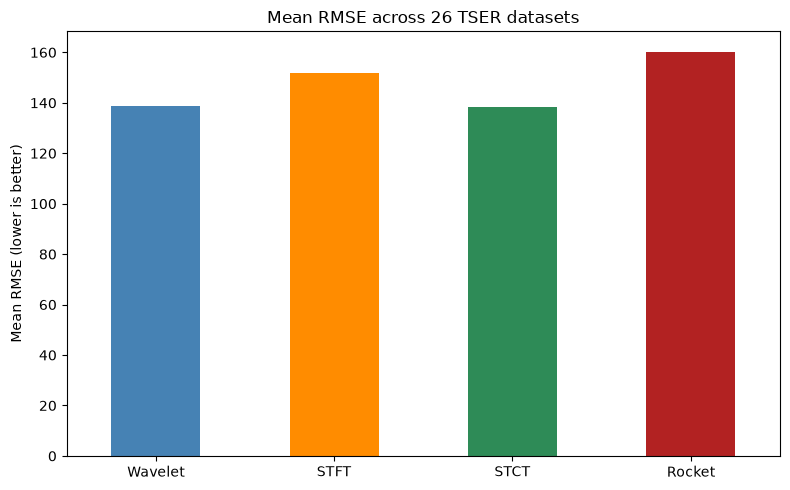

In [10]:
ax = full_results_df.set_index("dataset")[rmse_cols].mean().plot(
    kind="bar", figsize=(8, 5), color=["steelblue", "darkorange", "seagreen", "firebrick"])
ax.set_xticklabels(rep_cols)
ax.set_ylabel("Mean RMSE (lower is better)")
ax.set_title(f"Mean RMSE across {len(full_results_df)} TSER datasets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [11]:
space_time_summary = (
    full_results_long_df
    .groupby("representation")[["rmse", "mae", "r2", "n_features", "extract_time_s", "regressor_time_s"]]
    .mean()
)
space_time_summary["total_time_s"] = (
    space_time_summary["extract_time_s"].fillna(0) + space_time_summary["regressor_time_s"]
)
space_time_summary = space_time_summary.reindex(["Wavelet", "STFT", "STCT", "Rocket"])
space_time_summary.round(4)


,rmse,mae,r2,n_features,extract_time_s,regressor_time_s,total_time_s
representation,,,,,,,
Wavelet,138.8330,71.3839,-0.3160,1838.8077,0.0529,16.5340,16.5868
STFT,151.6660,73.0770,-2.3473,1954.9615,0.1684,17.9761,18.1445
STCT,138.3300,65.0858,-4.3142,133.8462,0.0792,1.4350,1.5142
Rocket,160.3249,104.6433,-0.7417,20000.0000,23.3298,1.2889,24.6187


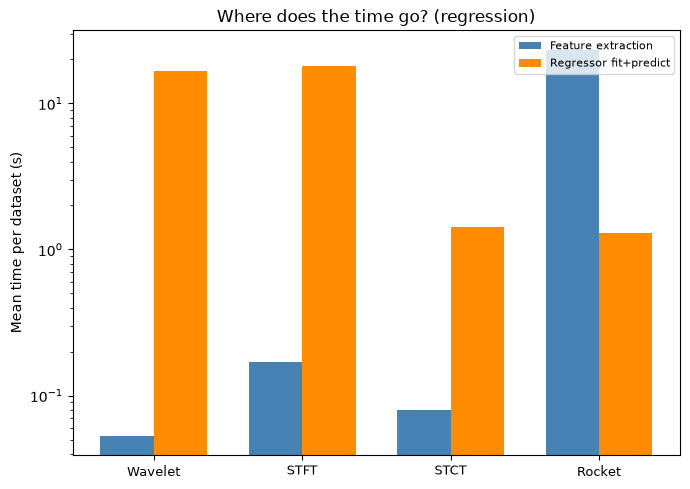

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
w = 0.36
x = np.arange(4)
ax.bar(x - w/2, space_time_summary["extract_time_s"], width=w, label="Feature extraction", color="steelblue")
ax.bar(x + w/2, space_time_summary["regressor_time_s"], width=w, label="Regressor fit+predict", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(["Wavelet", "STFT", "STCT", "Rocket"], fontsize=9)
ax.set_yscale("log")
ax.set_ylabel("Mean time per dataset (s)")
ax.set_title("Where does the time go? (regression)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 5b. Per-dataset view: RMSE gap and feature count

The mean RMSE above is dominated by datasets with large target scales. These cells show, **for every dataset**:

- **Top panel:** the relative RMSE reduction of STCT versus the best competing technique, `100 * (best_other - STCT) / best_other`. Positive (green) means STCT has the lowest RMSE; negative (red) means a competitor is better. A relative measure is used because raw RMSE is not comparable across datasets with different target units.
- **Bottom panel:** the number of features each technique uses on that dataset (log scale).

The sign convention matches the classification notebook (positive = STCT better). `INCLUDE_ROCKET_IN_BEST = False` keeps the reference set to the matched random-forest baselines; set it to `True` to include Rocket.

## 6. Statistical testing

Same methodology as the classification benchmark: paired Wilcoxon
signed-rank tests with Bonferroni correction, plus a Friedman omnibus test,
applied to RMSE (lower is better) across the three baselines.


In [15]:
def paired_significance_report(df, cols, label="", lower_is_better=True):
    valid_idx = df[cols].dropna().index
    arrs = {c: df.loc[valid_idx, c].values for c in cols}
    n = len(valid_idx)
    print(f"--- {label} (n={n} datasets with complete data) ---")
    if n < 3:
        print("Too few complete datasets for testing.")
        return None
    if len(cols) > 2:
        stat, p = stats.friedmanchisquare(*[arrs[c] for c in cols])
        print(f"Friedman omnibus: chi2={stat:.3f}, p={p:.4f}")
    from itertools import combinations
    pairs = list(combinations(cols, 2))
    alpha_corrected = 0.05 / len(pairs)
    rows = []
    for a, b in pairs:
        diffs = arrs[a] - arrs[b]
        if np.allclose(diffs, 0):
            print(f"{a} vs {b}: identical, skipping"); continue
        w, p = stats.wilcoxon(arrs[a], arrs[b])
        d = diffs.mean() / diffs.std(ddof=1) if diffs.std(ddof=1) > 0 else 0.0
        sig = "***" if p < alpha_corrected else ("*" if p < 0.05 else "")
        better = "a better" if (diffs.mean() < 0) == lower_is_better else "b better"
        rows.append({"comparison": f"{a} vs {b}", "mean_diff": diffs.mean(),
                      "wilcoxon_p": p, "cohens_d": d, "bonferroni_sig": p < alpha_corrected})
        print(f"{a:12s} vs {b:12s} | mean_diff={diffs.mean():+.4f} | p={p:.4f} {sig} | "
              f"d={d:.3f} | {better}")
    print(f"(Bonferroni-corrected alpha = {alpha_corrected:.4f} for {len(pairs)} comparisons; "
          f"lower RMSE is better, so a negative mean_diff for 'a vs b' means a beat b)")
    return pd.DataFrame(rows)

print("=" * 90)
baseline_stats = paired_significance_report(
    full_results_df, ["Wavelet_rmse", "STFT_rmse", "STCT_rmse"], label="Baselines (RMSE)")


--- Baselines (RMSE) (n=26 datasets with complete data) ---
Friedman omnibus: chi2=7.000, p=0.0302
Wavelet_rmse vs STFT_rmse    | mean_diff=-12.8331 | p=0.9205  | d=-0.266 | a better
Wavelet_rmse vs STCT_rmse    | mean_diff=+0.5030 | p=0.0140 *** | d=0.007 | b better
STFT_rmse    vs STCT_rmse    | mean_diff=+13.3360 | p=0.0382 * | d=0.226 | b better
(Bonferroni-corrected alpha = 0.0167 for 3 comparisons; lower RMSE is better, so a negative mean_diff for 'a vs b' means a beat b)


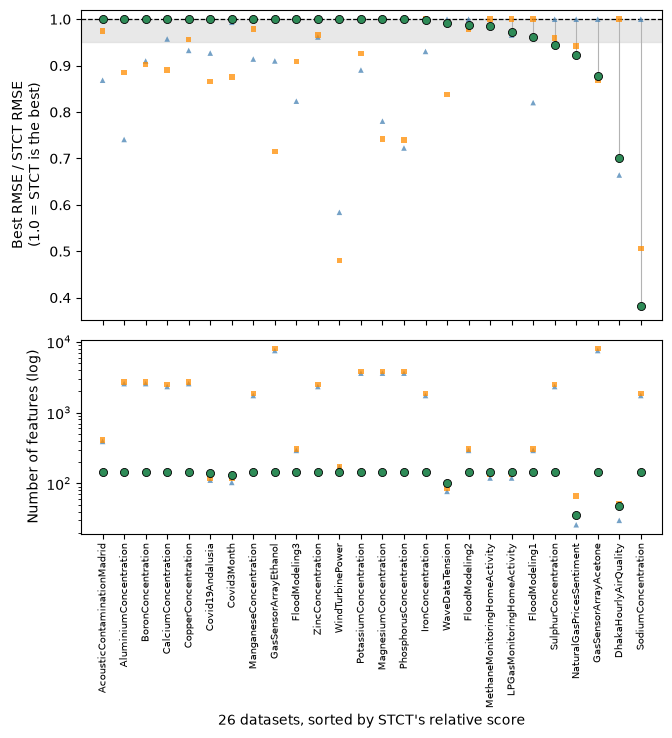

Caption numbers:
  Best technique per dataset: STCT 15, Wavelet 6, STFT 5.
  STCT is the best technique on 15/26 datasets and within 5% of the best on 21/26 (median relative score 1.000).
  Where another technique is best, it uses a median of 2.0x more features than STCT.


In [25]:
# ---- STCT relative to the best technique on each dataset (regression) ----
STCT = "STCT"
METHODS = ["Wavelet", "STFT", "STCT"]         # drop "Rocket" to use only the matched baselines
score = full_results_df.set_index("dataset")[[f"{m}_rmse" for m in METHODS]].dropna()
score.columns = METHODS
feats = (full_results_long_df.pivot_table(index="dataset", columns="representation", values="n_features")
         .reindex(score.index))
best_name = score.idxmin(axis=1)                       # lowest RMSE on each dataset (may be STCT itself)
rel_all = score.rdiv(score.min(axis=1), axis=0)        # best RMSE / each technique's RMSE; 1.0 = it is the best
YLABEL = "Best RMSE / STCT RMSE\n(1.0 = STCT is the best)"
TITLE = f"STCT relative to the best technique on each of {len(score)} TSER datasets"
FNAME = "relative_regression"

# ---- shared plotting body ----
NAMES = {"Chebyshev": "STCT"}
disp = lambda s: NAMES.get(s, s)
COLORS  = {"STCT": "seagreen", "Wavelet": "steelblue", "STFT": "darkorange", "Rocket": "firebrick"}
MARKERS = {"STCT": "o", "Wavelet": "^", "STFT": "s", "Rocket": "D"}

rel = rel_all[STCT]
best_disp = best_name.map(disp)
order = rel.sort_values(ascending=False).index          # datasets sorted by STCT's relative score
n = len(order); x = np.arange(n)
others = [m for m in METHODS if m != STCT]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(7.5, 0.11 * n + 3), 6.8), sharex=True,
                               gridspec_kw={"height_ratios": [1.6, 1], "hspace": 0.08})

# top: every technique relative to the best on that dataset; STCT emphasised
ax1.axhspan(0.95, 1.0, color="0.85", alpha=0.6, zorder=0)
ax1.axhline(1.0, color="k", ls="--", lw=0.9, zorder=1)
ax1.vlines(x, rel.loc[order].values, 1.0, color="0.7", lw=0.8, zorder=1)      # STCT's gap to the best
for m in others:
    ax1.scatter(x, rel_all.loc[order, m].values, marker=MARKERS[disp(m)], s=16, alpha=0.75,
                color=COLORS[disp(m)], edgecolor="none", zorder=2)
ax1.scatter(x, rel.loc[order].values, marker="o", s=34, color=COLORS["STCT"],
            edgecolor="k", linewidth=0.6, zorder=4)
ax1.set_ylim(max(0, rel_all.loc[order].min().min() - 0.03), 1.02)
ax1.set_ylabel(YLABEL)

# bottom: number of features of every technique; STCT emphasised
for m in others:
    ax2.scatter(x, feats.loc[order, m].values, marker=MARKERS[disp(m)], s=16, alpha=0.75,
                color=COLORS[disp(m)], edgecolor="none", zorder=2)
ax2.scatter(x, feats.loc[order, STCT].values, marker="o", s=34, color=COLORS["STCT"],
            edgecolor="k", linewidth=0.6, zorder=4)
ax2.set_yscale("log")
ax2.set_ylabel("Number of features (log)")
ax2.set_xlim(-1, n)
ax2.set_xlabel(f"{n} datasets, sorted by STCT's relative score")
if n <= 30:
    ax2.set_xticks(x); ax2.set_xticklabels(order, rotation=90, fontsize=7)

plt.savefig(FNAME + ".png", dpi=300, bbox_inches="tight")
plt.savefig(FNAME + ".pdf", bbox_inches="tight")
plt.show()

# numbers for the caption
n_best = int((rel >= 1 - 1e-12).sum()); n95 = int((rel >= 0.95).sum())
f_best = pd.Series([feats.loc[ds, best_name.loc[ds]] for ds in rel.index], index=rel.index)
mask = (best_name != STCT).values
ratio = (f_best / feats[STCT]).values[mask]
print("Caption numbers:")
print("  Best technique per dataset: " + ", ".join(f"{k} {v}" for k, v in best_disp.value_counts().items()) + ".")
print(f"  STCT is the best technique on {n_best}/{n} datasets and within 5% of the best on {n95}/{n} "
      f"(median relative score {rel.median():.3f}).")
if len(ratio):
    print(f"  Where another technique is best, it uses a median of {np.median(ratio):.1f}x more features than STCT.")

In [26]:
full_results_df.to_csv('results_regression.csv')

## 7. Reading this honestly

This is the first empirical test of the regression claim in Section IV of
the accompanying paper, "the same $\Psi(x)$ can feed a regressor... though
we flag this as a direct, unevaluated consequence of the design, not a
tested claim." This notebook is that test. Whatever the significance
testing above shows, either outcome is a real, reportable result:

- **If STCT's RMSE is significantly lower than wavelet and/or STFT**, the
  generality claim is empirically supported, not just structurally
  plausible, and the paper's Section IV should be updated from "proposed"
  to "validated."
- **If STCT does not significantly beat one or both baselines here**, that
  is still worth reporting plainly: classification and regression are
  different tasks, and there is no guarantee a representation that wins at
  one wins at the other. TSER datasets are also a smaller, less
  standardized benchmark collection than the UCR classification archive, so
  a single run here carries less statistical weight than the 116-dataset
  classification result.

Either way, do not average this result into the classification claim or
present the two as one finding, they are separate empirical questions.
